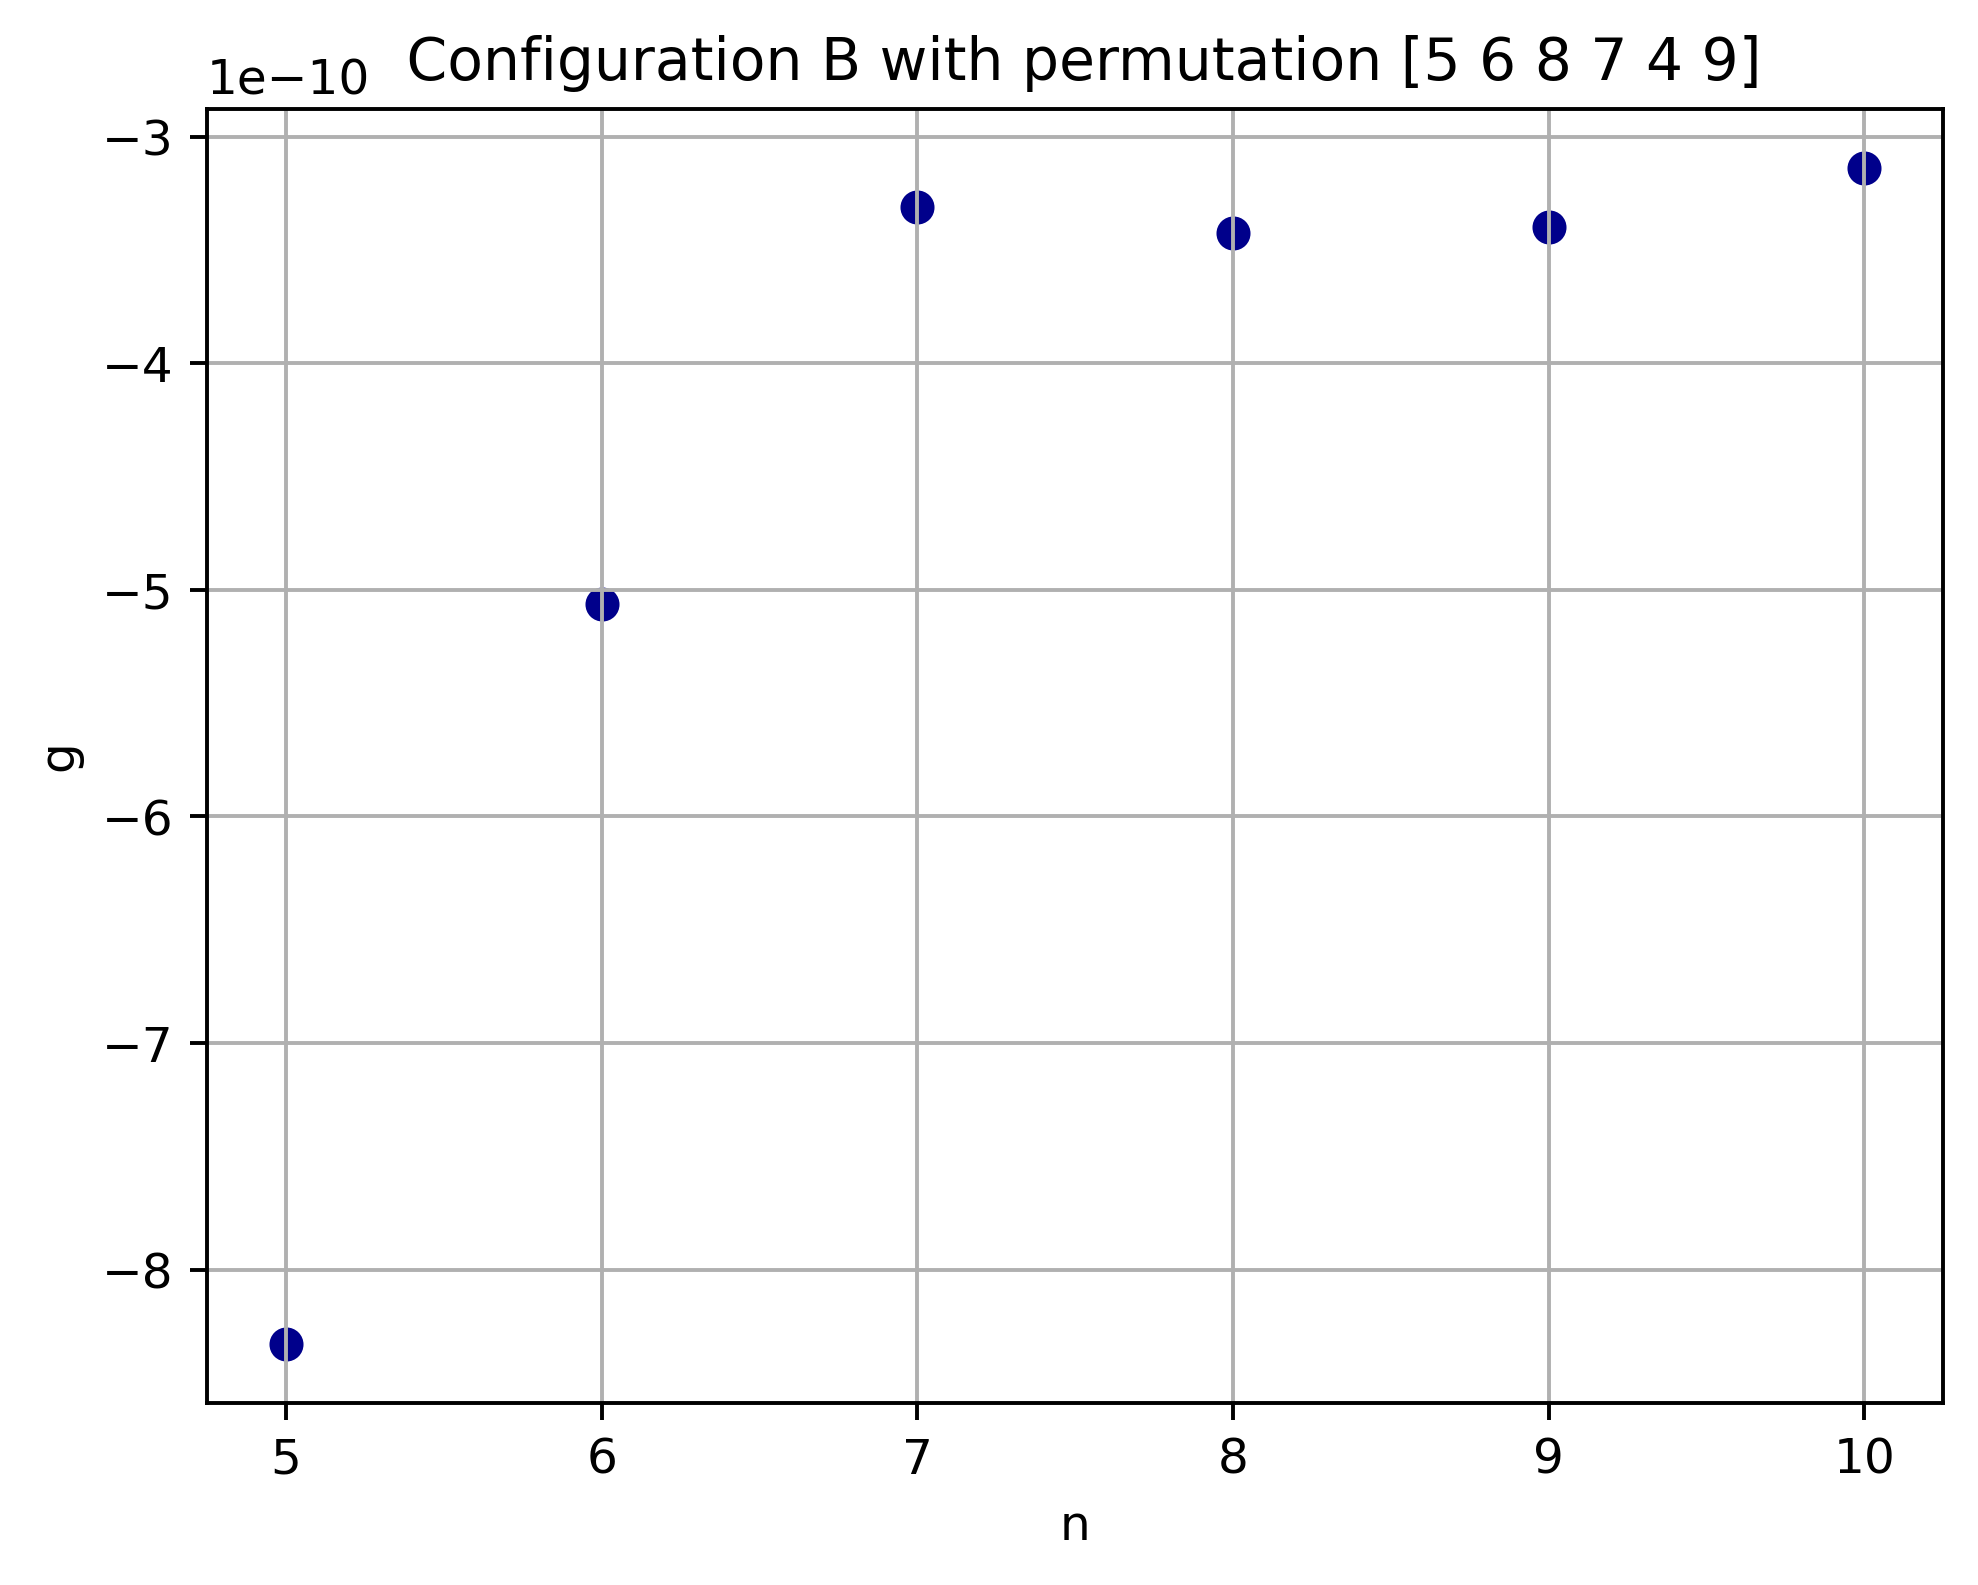

In [15]:
%matplotlib inline
import numpy as np
from utils import _build_redfield_numba, build_redfield_tensor, evolve_density_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit
plt.rcParams['figure.dpi']=350

#coupling params
J = 1e-1
eps = 1e-4 
Alpha=1e-6
Beta=10
Omega_c=50
J_max=1
power=3
D = np.array([[ 26.42338043,  -7.94752626],
              [ 23.5676572 , -10.82584156],
              [ 12.9945502 , -15.04985626],
              [ 10.04355896, -17.75500788],
              [ 22.09827259,  11.50615309],
              [  4.77769072, -29.50708222],
              [  3.61769485,  13.64602815],
              [-13.15603736,  -3.06908283],
              [ -7.72037927,  25.74900317],
              [-22.17787943,  18.52470886]])

rng = np.random.default_rng()
perm=rng.permutation(np.arange(4,10))
order=[0,1,2,3]
for j in range(len(perm)): 
    order.append(perm[j])
D=D[order]
def dens(alpha, wc, x): #J(w) spectral density function for baths
    return 2 * alpha * x * np.exp(-x / wc)

def eta(beta, x):  #the thermal factor
    return 1 / np.expm1(beta * x)  # better than exp(beta*x)-1 near x=0

#bath params- assuming 3 decoupled ohmic baths
def gap(n):
    alpha_list=np.array(Alpha*np.ones(n))
    wc_list=np.array(Omega_c*np.ones(n))
    beta_list=np.array(Beta*np.ones(n))
    '''
    H=np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i !=j:
                H[i,j]=eps
    H[0,1]=J
    H[1,0]=J
    H[2,3]=J
    H[3,2]=J
    '''
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                dist = np.linalg.norm(D[i] - D[j])
                H[i, j] = J_max / dist**power
  
    
    i, j = np.triu_indices(n, k=1)

    #mask = (i <= 3) & (j > 3)
    mask = ~(((i == 0) & (j == 1)) | ((i == 2) & (j == 3)))
    weak = np.average(H[i[mask], j[mask]])
    
    strong=J
    weak=eps
    expression=-((np.pi*Alpha)/(2*strong))*(-weak**2+(weak**2+weak**2)/np.tanh(strong*Beta/2))*(2+1/np.cosh(strong*Beta))-3.44*10**(-13)*(n-3)
    #system-bath coupling operators 
    S_list=[]
    for i in range(H.shape[0]):
        S=np.zeros((H.shape[0],H.shape[0]))
        S[i,i]=1
        S_list.append(S)

    def gamma_func(w): #Laplace transforms of bath correlation functions 
        gammas = []
        absw = abs(w)
        for alpha, wc, beta in zip(alpha_list, wc_list, beta_list):

            if absw < 1e-12:
                # Ohmic zero-frequency limit:
                # dens(alpha,wc,w) * eta(beta,w) -> 2 alpha / beta
                g = (np.pi/2)*(alpha/beta)
            elif w > 0:
                g = (np.pi/4)*dens(alpha,wc,absw)*(eta(beta,absw)+1) #ignoring the complex part with the Cauchy PV dist.
            else:
                g = (np.pi/4)*dens(alpha,wc,absw)*eta(beta,absw)
            gammas.append(g + 0j) #ensures dtype is complex with 0 complex part

        return np.array(gammas, dtype=np.complex128)

    R,U=build_redfield_tensor(H,S_list,gamma_func, False,1e-10,True) 

    eigenvalues=np.linalg.eigvals(R)
    #remove the ss noise
    ss_index = np.argmax(eigenvalues.real)
    eigenvalues = np.delete(eigenvalues, ss_index)
    gap = np.max(eigenvalues.real)
    
    return gap,expression

n_array=np.arange(5,11)
results = [gap(n) for n in n_array]

gap_array = np.array([result[0] for result in results])
exp_array = np.array([result[1] for result in results])

def linear_model(x,C,I):
    return C*x+I
popt,pcov=curve_fit(linear_model,n_array,gap_array)
plt.scatter(n_array,gap_array,color='darkblue',label='g(n)')
#plt.plot(n_array,linear_model(n_array,*popt),color='lightblue',ls='--',label=f'$({popt[0]:.3})n+({popt[1]:.3})$')
plt.xlabel('n')
#plt.legend()
plt.ylabel('g')
plt.title(f' Configuration B with permutation {perm}')
plt.grid()
plt.show()


In [10]:
n=7
H = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            dist = np.linalg.norm(D[i] - D[j])
            H[i, j] = J_max / dist**power
print(H)

[[0.00000000e+00 1.50021347e-02 2.85241309e-04 1.43707710e-04
  1.57677352e-05 9.05844417e-06 3.22799629e-05]
 [1.50021347e-02 0.00000000e+00 6.77527904e-04 2.84985635e-04
  1.89115598e-05 8.96822326e-06 3.17716658e-05]
 [2.85241309e-04 6.77527904e-04 0.00000000e+00 1.55867074e-02
  4.20177600e-05 1.04385998e-05 3.63455573e-05]
 [1.43707710e-04 2.84985635e-04 1.55867074e-02 0.00000000e+00
  4.83093733e-05 9.63729673e-06 3.03699040e-05]
 [1.57677352e-05 1.89115598e-05 4.20177600e-05 4.83093733e-05
  0.00000000e+00 3.96488656e-05 7.53082507e-05]
 [9.05844417e-06 8.96822326e-06 1.04385998e-05 9.63729673e-06
  3.96488656e-05 0.00000000e+00 2.19240402e-04]
 [3.22799629e-05 3.17716658e-05 3.63455573e-05 3.03699040e-05
  7.53082507e-05 2.19240402e-04 0.00000000e+00]]
